[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter11_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 11: Continuous-Time Models

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: pen and paper (A1–A8); Part B: estimation and inference (B1–B8); Part C: open question.

> The solutions are discussed in the seminar.

In [ ]:
import os
import re
import io
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
LightGray = '#DADADA'
MODEL_COL = {'Data': MainBlue, 'GBM': Orange, 'Merton': Purple, 'Heston': Forest}

HERE = '.'
CHART_DIR = '.'
SEED = 42
DT = 1 / 252


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels and not ll.startswith('_'):
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500 (1990–2026), BET (2000–2026), Bitcoin (2014–2026), VIX (1990–2026).
- 3-month US Treasury bill rate (FRED series DTB3), 1954–2026.
- Equity indices: weekdays only, days with an unchanged close removed; Bitcoin: 7 days a week; daily log returns, time in years.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, data de start)
MARKETS = {
    'sp500':  ('GSPC.INDX',  'S&P 500',                  'index',  '1990-01-01'),
    'bet':    ('BET',        'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC', 'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',    'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def read_fred(series, start='1954-01-01', end=END):
    """Serie zilnica FRED (Federal Reserve Bank of St. Louis), in unitatile originale."""
    key = ('fred', series, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}'
    for attempt in range(4):
        try:
            raw = urllib.request.urlopen(url, timeout=120).read().decode()
            break
        except OSError:
            if attempt == 3:
                raise
    df = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True, na_values='.')
    s = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().loc[start:end].rename(series)
    _CACHE[key] = s
    return s


def load_close(name, start=None, end=END):
    """Pretul zilnic, curatat dupa conventiile capitolului."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def load_vix(start='1990-01-01', end=END):
    """Indicele VIX (CBOE), nivelul zilnic de inchidere, in puncte de volatilitate anualizata (%)."""
    s = read_market('VIX.INDX')['close'].loc[start:end]
    s = s[(s > 0) & (s.index.dayofweek < 5)].dropna()
    return s.rename('vix')


# randamente log zilnice (nu in %), fiecare serie pe calendarul ei
rets = {k: log_returns(k) for k in ['sp500', 'bet', 'btc']}
DTS = {'sp500': 1 / 252, 'bet': 1 / 252, 'btc': 1 / 365}
for k, r in rets.items():
    print(f'{LABELS[k]:26s}', r.index[0].date(), '->', r.index[-1].date(), len(r), 'obs')

## Continuous-time models

- Brownian motion, quadratic variation, Itô and Stratonovich sums; Euler–Maruyama and Milstein.
- Geometric Brownian motion (GBM), Ornstein–Uhlenbeck (OU), Merton jump-diffusion, Lee–Mykland jump test, Heston stochastic volatility.
- Stylised facts: excess kurtosis, Hill tail index, autocorrelation of $|r_t|$.

In [ ]:
# =============================================================================
# MISCAREA BROWNIANA
# =============================================================================
def scaled_random_walk(n, n_paths, rng):
    """Mersul aleator scalat W_n(t) = S_[nt] / sqrt(n), cu pasi +1/-1 egal probabili, pe grila t = k/n."""
    steps = rng.choice([-1.0, 1.0], size=(n_paths, n))
    S = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(steps, axis=1)], axis=1)
    return np.linspace(0, 1, n + 1), S / np.sqrt(n)


def bm_paths(n_paths, n_steps, T, rng):
    """Traiectorii ale miscarii browniene standard pe [0, T]: W_0 = 0, cresteri N(0, dt) independente."""
    dt = T / n_steps
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)
    return np.linspace(0, T, n_steps + 1), W


def quadratic_variation(W):
    """Suma patratelor cresterilor (variatia patratica pe grila data)."""
    return np.sum(np.diff(W, axis=-1) ** 2, axis=-1)


def total_variation(W):
    """Suma valorilor absolute ale cresterilor (variatia totala pe grila data)."""
    return np.sum(np.abs(np.diff(W, axis=-1)), axis=-1)


def ito_stratonovich(W):
    """Sumele Ito (capatul stang) si Stratonovich (punctul de mijloc) pentru integrala lui W dupa W."""
    dW = np.diff(W, axis=-1)
    ito = np.sum(W[..., :-1] * dW, axis=-1)
    strat = np.sum(0.5 * (W[..., :-1] + W[..., 1:]) * dW, axis=-1)
    return ito, strat


def max_prob(W, level=1.0):
    """Proportia traiectoriilor al caror maxim pe [0, T] depaseste nivelul dat."""
    return float(np.mean(W.max(axis=1) > level))


# =============================================================================
# SCHEME DE DISCRETIZARE (ecuatia de test a lui Higham: dX = lam X dt + mu X dW)
# =============================================================================
def em_milstein_gbm(x0, lam, mu, dW, dt):
    """Euler-Maruyama si Milstein pentru dX = lam X dt + mu X dW, cu cresterile browniene dW (n_paths x n)."""
    xe = np.full(dW.shape[0], x0, dtype=float)
    xm = xe.copy()
    for k in range(dW.shape[1]):
        d = dW[:, k]
        xe = xe + lam * xe * dt + mu * xe * d
        xm = xm + lam * xm * dt + mu * xm * d + 0.5 * mu ** 2 * xm * (d ** 2 - dt)
    return xe, xm


def convergence_study(rng, x0=1.0, lam=2.0, mu=1.0, T=1.0, n_fine=2 ** 11, n_paths=20000,
                      ratios=(1, 2, 4, 8, 16, 32, 64)):
    """Eroarea tare E|X_T - X^h_T| si eroarea slaba |E X^h_T - E X_T| pentru pasi dt = ratio * T / n_fine."""
    dt_f = T / n_fine
    dW = rng.standard_normal((n_paths, n_fine)) * np.sqrt(dt_f)
    WT = dW.sum(axis=1)
    x_true = x0 * np.exp((lam - 0.5 * mu ** 2) * T + mu * WT)
    ex = x0 * np.exp(lam * T)                       # E X_T exact
    rows = []
    for r in ratios:
        dWr = dW.reshape(n_paths, n_fine // r, r).sum(axis=2)
        h = r * dt_f
        xe, xm = em_milstein_gbm(x0, lam, mu, dWr, h)
        rows.append(dict(dt=h, strong_em=np.mean(np.abs(x_true - xe)), strong_mil=np.mean(np.abs(x_true - xm)),
                         strong_em_se=np.std(np.abs(x_true - xe)) / np.sqrt(n_paths),
                         strong_mil_se=np.std(np.abs(x_true - xm)) / np.sqrt(n_paths),
                         weak_em_exact=abs(x0 * (1 + lam * h) ** round(T / h) - ex),
                         weak_em_mc=abs(xe.mean() - ex), weak_mil_mc=abs(xm.mean() - ex)))
    return pd.DataFrame(rows)


def slope_ci(dt, err, level=0.95):
    """Panta regresiei log(eroare) pe log(dt), cu eroare standard si interval de incredere t."""
    x, y = np.log(np.asarray(dt)), np.log(np.asarray(err))
    res = stats.linregress(x, y)
    q = stats.t.ppf(0.5 + level / 2, len(x) - 2)
    return dict(slope=res.slope, se=res.stderr, lo=res.slope - q * res.stderr, hi=res.slope + q * res.stderr,
                intercept=res.intercept)


# =============================================================================
# MISCAREA BROWNIANA GEOMETRICA (GBM)
# =============================================================================
def gbm_paths(S0, mu, sigma, T, n_steps, n_paths, rng):
    """Solutia exacta S_t = S_0 exp((mu - sigma^2/2) t + sigma W_t) pe o grila regulata."""
    t, W = bm_paths(n_paths, n_steps, T, rng)
    return t, S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * W)


def gbm_mle(r, dt):
    """Verosimilitate maxima pentru GBM din randamente log r (aceeasi frecventa dt, in ani).

    r_t ~ N((mu - sigma^2/2) dt, sigma^2 dt), i.i.d.  =>  sigma^2 = var(r)/dt,  mu = mean(r)/dt + sigma^2/2.
    Erori standard: se(sigma) = sigma / sqrt(2n); se(drift log) = sigma / sqrt(n dt) (depinde doar de durata)."""
    r = np.asarray(r)
    n = len(r)
    s2 = r.var() / dt
    sigma = np.sqrt(s2)
    m = r.mean() / dt                       # drift-ul logaritmului (mu - sigma^2/2)
    return dict(n=n, years=n * dt, sigma=sigma, se_sigma=sigma / np.sqrt(2 * n), m=m, se_m=sigma / np.sqrt(n * dt),
                mu=m + 0.5 * s2)


def gbm_simulate_returns(m, sigma, n, dt, rng):
    """Randamente log i.i.d. Normale ale unei GBM (drift log m, volatilitate sigma)."""
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)


# =============================================================================
# ORNSTEIN-UHLENBECK / VASICEK
# =============================================================================
def ou_exact_path(x0, kappa, theta, sigma, dt, n, rng, z=None):
    """Discretizarea exacta: x_{t+dt} = theta + (x_t - theta) e^{-kappa dt} + eps, eps ~ N(0, sigma^2 (1 - e^{-2 kappa dt}) / (2 kappa))."""
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    z = rng.standard_normal(n) if z is None else z
    x = np.empty(n + 1)
    x[0] = x0
    for k in range(n):
        x[k + 1] = theta + (x[k] - theta) * b + sd * z[k]
    return x


def ou_mle(x, dt):
    """Estimatorul de verosimilitate maxima (conditionat de x_0) al procesului OU: regresia AR(1) exacta.

    x_{t+1} = a + b x_t + e;  kappa = -ln b / dt;  theta = a / (1 - b);  sigma = s_e sqrt(2 kappa / (1 - b^2)).
    Erorile standard ale lui kappa, theta si ale timpului de injumatatire: metoda delta din covarianta OLS a (a, b)."""
    x = np.asarray(x, dtype=float)
    y, z = x[1:], x[:-1]
    X = np.column_stack([np.ones_like(z), z])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b = coef
    e = y - X @ coef
    n = len(y)
    s2 = e @ e / n
    cov = s2 * np.linalg.inv(X.T @ X)
    kappa = -np.log(b) / dt
    theta = a / (1 - b)
    sigma = np.sqrt(s2 * 2 * kappa / (1 - b ** 2))
    g_k = np.array([0.0, -1 / (b * dt)])                       # d kappa / d(a, b)
    g_t = np.array([1 / (1 - b), a / (1 - b) ** 2])           # d theta / d(a, b)
    se_k = float(np.sqrt(g_k @ cov @ g_k))
    se_t = float(np.sqrt(g_t @ cov @ g_t))
    hl = np.log(2) / kappa
    return dict(n=n, a=a, b=b, kappa=kappa, se_kappa=se_k, theta=theta, se_theta=se_t, sigma=sigma,
                half_life=hl, se_half_life=hl / kappa * se_k, stat_sd=sigma / np.sqrt(2 * kappa))


def ou_bias_mc(kappa, theta, sigma, dt, n, n_sim, rng):
    """Distributia de selectie a lui kappa estimat: n_sim traiectorii OU exacte (start din distributia stationara)."""
    from scipy.signal import lfilter
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    out = np.empty(n_sim)
    for i in range(n_sim):
        e = sd * rng.standard_normal(n)
        e[0] = sigma / np.sqrt(2 * kappa) * rng.standard_normal()
        x = theta + lfilter([1.0], [1.0, -b], e)
        out[i] = ou_mle(x, dt)['kappa']
    return out


# =============================================================================
# MERTON: DIFUZIE CU SALTURI
# =============================================================================
def merton_logpdf(r, dt, m, sigma, lam, mu_j, s_j, kmax=12):
    """Log-densitatea randamentelor log pe un pas dt:  r = m dt + sigma W_dt + suma a N salturi N(mu_j, s_j^2),
    N ~ Poisson(lam dt). Densitatea este o mixtura de distributii Normale ponderate cu probabilitatile Poisson."""
    r = np.asarray(r)[:, None]
    k = np.arange(kmax + 1)[None, :]
    w = stats.poisson.pmf(k, lam * dt)
    mean = m * dt + k * mu_j
    var = sigma ** 2 * dt + k * s_j ** 2
    dens = (w * np.exp(-0.5 * (r - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)).sum(axis=1)
    return np.log(np.maximum(dens, 1e-300))


def _merton_unpack(p):
    return p[0], np.exp(p[1]), np.exp(p[2]), p[3], np.exp(p[4])


def merton_mle(r, dt, starts=None):
    """Verosimilitate maxima pentru Merton (m, sigma, lam, mu_j, s_j); mai multe puncte de start.
    Erorile standard: inversa hessianei numerice in parametrii originali (metoda delta)."""
    r = np.asarray(r)
    sd = r.std()
    nll = lambda p: -merton_logpdf(r, dt, *_merton_unpack(p)).sum()
    if starts is None:
        starts = []
        for lam0 in (2.0, 10.0, 40.0):
            for sj0 in (1.5, 3.0):
                starts.append([r.mean() / dt, np.log(0.7 * sd / np.sqrt(dt)), np.log(lam0), -0.5 * sd, np.log(sj0 * sd)])
    best = None
    for s0 in starts:
        res = optimize.minimize(nll, s0, method='Nelder-Mead', options=dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-7))
        res = optimize.minimize(nll, res.x, method='BFGS')
        if best is None or res.fun < best.fun:
            best = res
    m, sigma, lam, mu_j, s_j = _merton_unpack(best.x)
    theta = np.array([m, sigma, lam, mu_j, s_j])
    nll_orig = lambda th: -merton_logpdf(r, dt, *th).sum()
    H = numerical_hessian(nll_orig, theta)
    try:
        cov = np.linalg.inv(H)
        se = np.sqrt(np.maximum(np.diag(cov), 0))
    except np.linalg.LinAlgError:
        se = np.full(5, np.nan)
    return dict(m=m, sigma=sigma, lam=lam, mu_j=mu_j, s_j=s_j, se=dict(zip(['m', 'sigma', 'lam', 'mu_j', 's_j'], se)),
                loglik=-best.fun, n=len(r))


def numerical_hessian(f, x, rel=1e-4):
    """Hessiana prin diferente finite centrale."""
    x = np.asarray(x, dtype=float)
    k = len(x)
    h = rel * np.maximum(np.abs(x), 1e-3)
    H = np.empty((k, k))
    for i in range(k):
        for j in range(i, k):
            ei, ej = np.zeros(k), np.zeros(k)
            ei[i], ej[j] = h[i], h[j]
            H[i, j] = H[j, i] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])
    return H


def merton_moments(dt, sigma, lam, mu_j, s_j, m=0.0):
    """Media, dispersia, asimetria si excesul de aplatizare ale randamentului Merton pe un pas dt (cumulanti)."""
    k1 = m * dt + lam * dt * mu_j
    k2 = sigma ** 2 * dt + lam * dt * (mu_j ** 2 + s_j ** 2)
    k3 = lam * dt * (mu_j ** 3 + 3 * mu_j * s_j ** 2)
    k4 = lam * dt * (mu_j ** 4 + 6 * mu_j ** 2 * s_j ** 2 + 3 * s_j ** 4)
    return dict(mean=k1, var=k2, skew=k3 / k2 ** 1.5, exkurt=k4 / k2 ** 2)


def merton_simulate_returns(m, sigma, lam, mu_j, s_j, n, dt, rng):
    """Randamente log simulate din modelul Merton."""
    N = rng.poisson(lam * dt, n)
    jumps = mu_j * N + s_j * np.sqrt(N) * rng.standard_normal(n)
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n) + jumps


def lr_bootstrap(r, dt, n_boot, rng):
    """Testul raportului de verosimilitate GBM (fara salturi) vs Merton, cu valoarea p din bootstrap parametric.
    Sub ipoteza nula lam = 0 se afla pe frontiera, iar mu_j, s_j nu sunt identificati: distributia chi-patrat nu se aplica."""
    r = np.asarray(r)
    g = gbm_mle(r, dt)
    ll0 = stats.norm.logpdf(r, r.mean(), r.std()).sum()
    mf = merton_mle(r, dt)
    lr = 2 * (mf['loglik'] - ll0)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        rb = gbm_simulate_returns(g['m'], g['sigma'], len(r), dt, rng)
        l0 = stats.norm.logpdf(rb, rb.mean(), rb.std()).sum()
        mb = merton_mle(rb, dt, starts=[[rb.mean() / dt, np.log(rb.std() / np.sqrt(dt)), np.log(5.0), 0.0, np.log(2 * rb.std())],
                                        [rb.mean() / dt, np.log(0.8 * rb.std() / np.sqrt(dt)), np.log(30.0), 0.0, np.log(1.5 * rb.std())]])
        boot[i] = max(2 * (mb['loglik'] - l0), 0.0)
    return dict(lr=lr, p_boot=float(np.mean(boot >= lr)), boot=boot, crit95=float(np.quantile(boot, 0.95)), merton=mf)


# =============================================================================
# TESTUL DE SALTURI LEE-MYKLAND
# =============================================================================
def lee_mykland(r, K=16, alpha=0.01):
    """Statistica L_t = r_t / sigma_t, cu sigma_t^2 = variatia bipower pe cele K-1 randamente anterioare;
    salt detectat daca (|L_t| - C_n) / S_n depaseste cuantila 1 - alpha a distributiei Gumbel (Lee & Mykland, 2008)."""
    r = pd.Series(r).dropna()
    a = r.abs()
    bpv = (a * a.shift(1)).rolling(K - 2).sum().shift(1) / (K - 2)
    L = (r / np.sqrt(bpv)).dropna()
    n = len(L)
    c = np.sqrt(2 / np.pi)
    ln = np.log(n)
    Cn = np.sqrt(2 * ln) / c - (np.log(np.pi) + np.log(ln)) / (2 * c * np.sqrt(2 * ln))
    Sn = 1 / (c * np.sqrt(2 * ln))
    crit = -np.log(-np.log(1 - alpha))
    stat = (L.abs() - Cn) / Sn
    return pd.DataFrame({'r': r.reindex(L.index), 'L': L, 'stat': stat, 'jump': stat > crit}), crit


# =============================================================================
# HESTON: VOLATILITATE STOCHASTICA
# =============================================================================
def heston_paths(S0, v0, mu, kappa, theta, xi, rho, T, n_steps, n_paths, rng, antithetic=False):
    """Schema Euler cu trunchiere completa (Lord et al., 2010) pentru log S si v.
    d ln S = (mu - v/2) dt + sqrt(v) dW1;  dv = kappa (theta - v) dt + xi sqrt(v) dW2;  corr(dW1, dW2) = rho."""
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    x = np.full(n_paths, np.log(S0))
    v = np.full(n_paths, v0, dtype=float)
    X = np.empty((n_steps + 1, n_paths))
    V = np.empty((n_steps + 1, n_paths))
    X[0], V[0] = x, v
    for k in range(n_steps):
        z1 = rng.standard_normal(m)
        z2 = rng.standard_normal(m)
        if antithetic:
            z1, z2 = np.concatenate([z1, -z1]), np.concatenate([z2, -z2])
        w2 = rho * z1 + np.sqrt(1 - rho ** 2) * z2
        vp = np.maximum(v, 0.0)
        x = x + (mu - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * w2
        X[k + 1], V[k + 1] = x, np.maximum(v, 0.0)
    return np.linspace(0, T, n_steps + 1), np.exp(X), V


def heston_from_vix(vix, logret, dt):
    """Parametrii Heston din VIX: v_t = (VIX_t / 100)^2 ca aproximare a variantei; regresia CIR discretizata
    (v_{t+1} - v_t) / sqrt(v_t) = kappa theta dt / sqrt(v_t) - kappa dt sqrt(v_t) + xi sqrt(dt) eps;
    rho = corelatia dintre socurile de randament si socurile de varianta."""
    d = pd.concat([vix.rename('vix'), logret.rename('r')], axis=1, join='inner').dropna()
    v = (d['vix'] / 100) ** 2
    y = (v.shift(-1) - v) / np.sqrt(v)
    X = np.column_stack([dt / np.sqrt(v), -dt * np.sqrt(v)])
    ok = y.notna().values
    beta, *_ = np.linalg.lstsq(X[ok], y.values[ok], rcond=None)
    kappa = beta[1]
    theta = beta[0] / kappa
    res = y.values[ok] - X[ok] @ beta
    xi = res.std() / np.sqrt(dt)
    dv = (v.shift(-1) - v - kappa * (theta - v) * dt) / np.sqrt(v)
    zr = (d['r'].shift(-1) - d['r'].mean()) / np.sqrt(v)
    rho = pd.concat([dv, zr], axis=1).dropna().corr().iloc[0, 1]
    return dict(kappa=kappa, theta=theta, xi=xi, rho=rho, v0=float(v.iloc[-1]), n=int(ok.sum()),
                feller=2 * kappa * theta / xi ** 2, mean_vix=float(d['vix'].mean()),
                real_var=float(d['r'].var() / dt))


def heston_from_proxy(logret, dt, window=21):
    """Aceeasi regresie CIR, cu varianta aproximata prin varianta realizata anualizata pe o fereastra mobila
    (pentru piete fara un indice de volatilitate, de exemplu BET si Bitcoin)."""
    rv = (logret ** 2).rolling(window).mean() / dt
    proxy = 100 * np.sqrt(rv)
    return heston_from_vix(proxy.dropna(), logret, dt)


def heston_simulate_returns(p, n, dt, rng, mu=0.0, burn=500):
    """Randamente log zilnice simulate din Heston (cu o perioada de incalzire de burn pasi)."""
    T = (n + burn) * dt
    _, S, _ = heston_paths(1.0, p['theta'], mu, p['kappa'], p['theta'], p['xi'], p['rho'], T, n + burn, 1, rng)
    return np.diff(np.log(S[:, 0]))[burn:]


def bs_call(S, K, T, sigma, r=0.0):
    """Pretul Black-Scholes al unei optiuni call europene."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d1 - sigma * np.sqrt(T))


def implied_vol(price, S, K, T, r=0.0):
    """Volatilitatea implicita Black-Scholes (radacina prin metoda Brent)."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    return optimize.brentq(lambda s: bs_call(S, K, T, s, r) - price, 1e-4, 5.0)


def heston_smile(p, T, strikes, rng, n_paths=100000, n_steps=126):
    """Preturi Monte Carlo ale optiunilor call sub Heston (rata zero, mu = 0) si volatilitatile implicite."""
    _, S, _ = heston_paths(1.0, p['v0'], 0.0, p['kappa'], p['theta'], p['xi'], p['rho'], T, n_steps, n_paths, rng,
                           antithetic=True)
    ST = S[-1] / S[-1].mean()                 # corectie de martingal: E[S_T] = S_0 = 1
    return np.array([implied_vol(np.maximum(ST - K, 0).mean(), 1.0, K, T) for K in strikes])


# =============================================================================
# FAPTE STILIZATE
# =============================================================================
def acf(x, lags):
    x = np.asarray(x) - np.mean(x)
    d = x @ x
    return np.array([x[k:] @ x[:-k] / d for k in lags])


def hill(x, share=0.05):
    """Estimatorul Hill al indicelui de coada pentru cele mai mari share din valori (pierderi)."""
    x = np.sort(np.asarray(x))[::-1]
    k = int(share * len(x))
    return 1 / np.mean(np.log(x[:k] / x[k]))


def stylised(r, lags=range(1, 51)):
    """Faptele stilizate folosite pentru compararea modelelor cu datele."""
    r = np.asarray(r)
    a = acf(np.abs(r), list(lags))
    return dict(exkurt=float(stats.kurtosis(r)), skew=float(stats.skew(r)), hill=float(hill(-r)),
                acf_abs1=float(a[0]), acf_abs_sum20=float(a[:20].sum()), acf_r1=float(acf(r, [1])[0]),
                acf_abs=a)

## Seminar functions

- Simulation of the stylised facts of a fitted model (used in Part C).

In [ ]:
def simulate_stats(model, p, n, dt, n_sim, rng, mu=0.0):
    out = []
    for _ in range(n_sim):
        if model == 'GBM':
            x = gbm_simulate_returns(p['m'], p['sigma'], n, dt, rng)
        elif model == 'Merton':
            x = merton_simulate_returns(p['m'], p['sigma'], p['lam'], p['mu_j'], p['s_j'], n, dt, rng)
        else:
            x = heston_simulate_returns(p, n, dt, rng, mu=mu)
        out.append(stylised(x))
    return out

## Part A — pen and paper

### A1. Itô's lemma for ln S [Solved]

- GBM with $\mu = 8\%$, $\sigma = 20\%$: mean and median of $S_{10}/S_0$, probability of a loss, probability of ending below the mean.

In [6]:
# Solution
def a1_gbm(mu=0.08, sigma=0.20, T=10.0):
    """A1: lema lui Ito pentru ln S; media, mediana si probabilitatea unei pierderi dupa T ani."""
    m = mu - 0.5 * sigma ** 2
    z = -m * np.sqrt(T) / sigma
    return dict(m=m, mean=np.exp(mu * T), median=np.exp(m * T), z=z, p_loss=stats.norm.cdf(z),
                p_below_mean=stats.norm.cdf(0.5 * sigma * np.sqrt(T)))


{k: round(v, 4) for k, v in a1_gbm().items()}

{'m': 0.06,
 'mean': np.float64(2.2255),
 'median': np.float64(1.8221),
 'z': np.float64(-0.9487),
 'p_loss': np.float64(0.1714),
 'p_below_mean': np.float64(0.6241)}

### A2. Siegel's paradox [Proposed]

- EUR/RON as GBM with $\mu = 2\%$, $\sigma = 4.4\%$; drift of $1/X$. Model: A1.

In [ ]:
# Your code here


### A3. Quadratic variation of Brownian motion [Solved]

- Mean and variance of $\sum(\Delta W)^2$ and mean total variation for $T = 1$, $n = 252$.

In [8]:
# Solution
def a3_qv(T=1.0, n=252):
    """A3: media si dispersia variatiei patratice pe o grila de n intervale; media variatiei totale."""
    return dict(mean=T, var=2 * T ** 2 / n, sd=np.sqrt(2 * T ** 2 / n), tv=np.sqrt(2 * n * T / np.pi),
                tv_1000=np.sqrt(2 * 1000 * n * T / np.pi) / np.sqrt(1000))


a3_qv()

{'mean': 1.0,
 'var': 0.007936507936507936,
 'sd': np.float64(0.0890870806374748),
 'tv': np.float64(12.666024736934256),
 'tv_1000': np.float64(12.666024736934256)}

### A4. The Itô integral of W with respect to W [Proposed]

- Mean, variance, and the Stratonovich integral. Model: A3.

In [ ]:
# Your code here


### A5. Vasicek, step by step [Solved]

- $\kappa = 0.5$, $\theta = 3\%$, $\sigma = 1\%$, $r_0 = 6\%$: half-life, moments of $r_1$, probability of a negative rate.

In [10]:
# Solution
def a5_ou(kappa=0.5, theta=0.03, sigma=0.01, r0=0.06, h=1.0):
    """A5: Vasicek: timpul de injumatatire, media si abaterea standard conditionate, distributia stationara."""
    e = np.exp(-kappa * h)
    cm = theta + (r0 - theta) * e
    cv = sigma ** 2 * (1 - e ** 2) / (2 * kappa)
    ssd = sigma / np.sqrt(2 * kappa)
    return dict(hl=np.log(2) / kappa, e=e, cmean=cm, csd=np.sqrt(cv), ssd=ssd, p_neg=stats.norm.cdf(-theta / ssd),
                p_neg_1y=stats.norm.cdf(-cm / np.sqrt(cv)))


a5_ou()

{'hl': np.float64(1.3862943611198906),
 'e': np.float64(0.6065306597126334),
 'cmean': np.float64(0.048195919791379),
 'csd': np.float64(0.007950600976206501),
 'ssd': np.float64(0.01),
 'p_neg': np.float64(0.001349898031630093),
 'p_neg_1y': np.float64(6.725238940173755e-10)}

### A6. From an AR(1) to an OU process [Proposed]

- Monthly AR(1): $a = 0.0012$, $b = 0.97$, $s = 0.0025$. Model: A5.

In [ ]:
# Your code here


### A7. Cumulants of the Merton return [Solved]

- $\sigma = 15\%$, $\lambda = 5$, $\mu_J = -3\%$, $\sigma_J = 4\%$, daily step.

In [12]:
# Solution
def a7_merton(sigma=0.15, lam=5.0, mu_j=-0.03, s_j=0.04, dt=1 / 252):
    """A7: cumulantii randamentului zilnic Merton."""
    mo = merton_moments(dt, sigma, lam, mu_j, s_j)
    diff_var = sigma ** 2 * dt
    jump_var = lam * dt * (mu_j ** 2 + s_j ** 2)
    return dict(mo, diff_var=diff_var, jump_var=jump_var, jump_share=jump_var / (diff_var + jump_var),
                k3=lam * dt * (mu_j ** 3 + 3 * mu_j * s_j ** 2), k4=lam * dt * (mu_j ** 4 + 6 * mu_j ** 2 * s_j ** 2 + 3 * s_j ** 4),
                p_jump_day=1 - np.exp(-lam * dt), p_jump_year=1 - np.exp(-lam))


a7_merton()

{'mean': -0.0005952380952380952,
 'var': 0.00013888888888888886,
 'skew': -2.0728330214211375,
 'exkurt': 17.61942857142858,
 'diff_var': 8.928571428571427e-05,
 'jump_var': 4.96031746031746e-05,
 'jump_share': 0.3571428571428572,
 'k3': -3.392857142857143e-06,
 'k4': 3.398809523809524e-07,
 'p_jump_day': np.float64(0.019645727253408407),
 'p_jump_year': np.float64(0.9932620530009145)}

### A8. Rare, large jumps [Proposed]

- $\lambda = 0.5$, $\mu_J = -10\%$, $\sigma_J = 5\%$. Model: A7.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. Orders of convergence [Solved]

- Slopes of log error on log step size with 95% CIs; the Monte Carlo noise floor.
- Interpretation: why does the Monte Carlo weak error give a wrong slope?

In [14]:
# Solution
def b1_convergence():
    """B1: ordinele de convergenta estimate prin regresie log-log, cu intervale de incredere de 95%."""
    rng = np.random.default_rng(SEED + 4)
    d = convergence_study(rng)
    se = slope_ci(d['dt'], d['strong_em'])
    sm = slope_ci(d['dt'], d['strong_mil'])
    we = slope_ci(d['dt'], d['weak_em_exact'])
    wm = slope_ci(d['dt'], d['weak_em_mc'])
    x_sd = np.exp(2.0) * np.sqrt(np.exp(1.0) - 1)            # abaterea standard a lui X_T (lam = 2, mu = 1, T = 1)
    w_small = float(d['weak_em_exact'].iloc[0])
    return dict(em=se, mil=sm, weak=we, weak_mc=wm, x_sd=x_sd, se_mc=x_sd / np.sqrt(20000),
                weak_small=w_small, m_needed=(1.96 * x_sd / w_small) ** 2, dt_small=float(d['dt'].iloc[0]))


b1_convergence()

{'em': {'slope': np.float64(0.5183286499303531),
  'se': np.float64(0.00363593330601912),
  'lo': np.float64(0.5089821858183152),
  'hi': np.float64(0.527675114042391),
  'intercept': np.float64(1.5447000222701894)},
 'mil': {'slope': np.float64(0.98575881255588),
  'se': np.float64(0.003490571256065948),
  'lo': np.float64(0.9767860134890427),
  'hi': np.float64(0.9947316116227174),
  'intercept': np.float64(2.745813716400905)},
 'weak': {'slope': np.float64(0.985127128601786),
  'se': np.float64(0.003563801316046232),
  'lo': np.float64(0.9759660856729407),
  'hi': np.float64(0.9942881715306312),
  'intercept': np.float64(2.590471619927935)},
 'weak_mc': {'slope': np.float64(0.5109008149404114),
  'se': np.float64(0.052366938189419954),
  'lo': np.float64(0.37628731484279887),
  'hi': np.float64(0.6455143150380239),
  'intercept': np.float64(0.8422275978452609)},
 'x_sd': np.float64(9.685814837659883),
 'se_mc': np.float64(0.06848905353026583),
 'weak_small': 0.0072076630501598515,
 

### B2. GBM on the S&P 500 [Solved]

- MLE with standard errors, Jarque–Bera, Ljung–Box on $|r_t|$, variance ratio.
- Interpretation: which parameter is known well and which one badly?

In [15]:
# Solution
def b2_gbm(key='sp500'):
    """B2/B3: GBM pe date: estimari cu erori standard, testul Jarque-Bera, testul Ljung-Box pe |r|, ani necesari."""
    r = rets[key]
    dt = DTS[key]
    g = gbm_mle(r.values, dt)
    jb = stats.jarque_bera(r.values)
    a = np.abs(r.values) - np.abs(r.values).mean()
    n = len(a)
    ac = np.array([a[k:] @ a[:-k] / (a @ a) for k in range(1, 21)])
    lb = n * (n + 2) * np.sum(ac ** 2 / (n - np.arange(1, 21)))
    q20 = [r.values[i:i + 20].sum() for i in range(0, n - 19, 20)]
    vr = np.var(q20) / (20 * r.var())
    return dict(g, m_lo=g['m'] - 1.96 * g['se_m'], m_hi=g['m'] + 1.96 * g['se_m'], jb=float(jb.statistic),
                jb_p=float(jb.pvalue), lb=float(lb), lb_crit=float(stats.chi2.ppf(0.95, 20)), acf1=float(ac[0]),
                years_1pp=float((1.96 * g['sigma'] / 0.01) ** 2), start=str(r.index[0].date()), vr20=float(vr),
                exkurt=float(stats.kurtosis(r.values)))


b2_gbm('sp500')

{'n': 9240,
 'years': 36.666666666666664,
 'sigma': np.float64(0.17995506876340506),
 'se_sigma': np.float64(0.0013237717245281652),
 'm': np.float64(0.08338046549432662),
 'se_m': np.float64(0.029718601508899732),
 'mu': np.float64(0.09957237888114755),
 'm_lo': np.float64(0.025132006536883147),
 'm_hi': np.float64(0.1416289244517701),
 'jb': 45717.63926014909,
 'jb_p': 0.0,
 'lb': 13388.545011954906,
 'lb_crit': 31.410432844230925,
 'acf1': 0.27457690681032093,
 'years_1pp': 1244.0570893362246,
 'start': '1990-01-03',
 'vr20': 0.798980675006292,
 'exkurt': 10.872824529252387}

### B3. GBM on BET and Bitcoin [Proposed]

- Same tests as B2. Model: B2.
- Interpretation: which market is further from GBM, and in which dimension?

In [ ]:
# Your code here


### B4. Vasicek and the bias of the mean-reversion speed [Solved]

- 3-month Treasury bill rate (DTB3), exact AR(1) MLE; 500 simulated samples for the bias.
- Interpretation: is mean reversion significant after the bias correction?

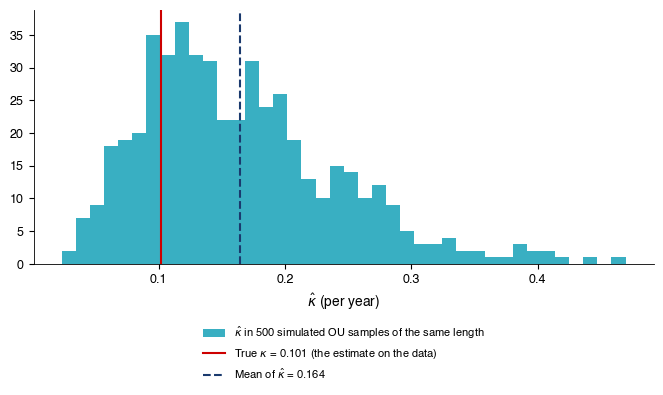

{'n': 18169,
 'a': np.float64(1.8323320445145317e-05),
 'b': np.float64(0.9995975062106368),
 'kappa': np.float64(0.10144885255591547),
 'se_kappa': 0.05144088306605011,
 'theta': np.float64(0.04552447995318332),
 'se_theta': 0.015535908651878474,
 'sigma': np.float64(0.013288258172257171),
 'half_life': np.float64(6.8324792552769775),
 'se_half_life': np.float64(3.4644922792812998),
 'stat_sd': np.float64(0.0295005076722635),
 'n_obs': 18170,
 'years': 72.1031746031746,
 'start': '1954-01-04',
 'k_mean': 0.16403549872671033,
 'k_sd': 0.0779952088249384,
 'bias': 0.06258664617079486,
 'k_corr': 0.03886220638512061,
 'hl_corr': 17.836022321813783,
 'share_above': 0.78,
 'approx_bias': 0.05547605943863512,
 'k_lo': np.float64(0.0006247217464572657),
 'k_hi': np.float64(0.2022729833653737)}

In [17]:
# Solution
def b4_vasicek(n_sim=500):
    """B4: Vasicek pe randamentul titlurilor de stat pe 3 luni; deplasarea lui kappa estimat prin simulare."""
    tb = read_fred('DTB3') / 100
    f = ou_mle(tb.values, DT)
    rng = np.random.default_rng(SEED + 20)
    k = ou_bias_mc(f['kappa'], f['theta'], f['sigma'], DT, len(tb), n_sim, rng)
    bias = k.mean() - f['kappa']
    kc = f['kappa'] - bias
    fig, ax = plt.subplots(figsize=(8, 3.3))
    ax.hist(k, bins=40, color=Teal, alpha=0.85, label=rf'$\hat\kappa$ in {n_sim} simulated OU samples of the same length')
    ax.axvline(f['kappa'], color=IDAred, lw=1.5, label=rf"True $\kappa$ = {f['kappa']:.3f} (the estimate on the data)")
    ax.axvline(k.mean(), color=MainBlue, lw=1.5, ls='--', label=rf'Mean of $\hat\kappa$ = {k.mean():.3f}')
    ax.set_xlabel(r'$\hat\kappa$ (per year)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch11_sem_kappa_bias')
    years = len(tb) * DT
    return dict(f, n_obs=len(tb), years=years, start=str(tb.index[0].date()), k_mean=float(k.mean()),
                k_sd=float(k.std()), bias=float(bias), k_corr=float(kc), hl_corr=float(np.log(2) / kc) if kc > 0 else None,
                share_above=float(np.mean(k > f['kappa'])), approx_bias=4 / years,
                k_lo=f['kappa'] - 1.96 * f['se_kappa'], k_hi=f['kappa'] + 1.96 * f['se_kappa'])


b4_vasicek()

### B5. Mean reversion of the VIX [Proposed]

- OU on ln VIX: half-life with CI, bias, ACF against the OU decay. Model: B4.
- Interpretation: what does the ACF pattern say about a one-factor OU model?

In [ ]:
# Your code here


### B6. Merton and a bootstrap likelihood-ratio test [Solved]

- MLE with Hessian standard errors; LR against GBM; parametric bootstrap with 200 samples.
- Interpretation: why is the $\chi^2_3$ distribution not valid here?

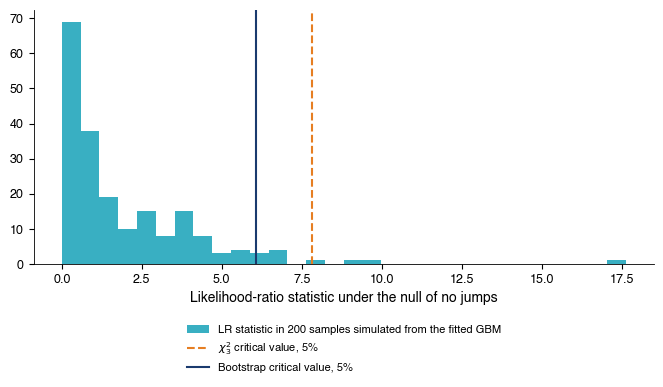

{'lr': np.float64(2396.724564090364),
 'p_boot': 0.0,
 'crit95': 6.0663749404389815,
 'chi2': 7.8147279032511765,
 'boot_mean': 1.9042059466476349,
 'boot_zero': 0.015,
 'moments': {'mean': np.float64(0.00033087488166332914),
  'var': np.float64(0.00012079474782583372),
  'skew': np.float64(-0.3102062487098191),
  'exkurt': np.float64(3.711578197692704)},
 'n_boot': 200}

In [19]:
# Solution
def b6_merton_lr(n_boot=200):
    """B6: Merton pe S&P 500: parametri cu erori standard; testul LR GBM vs Merton cu bootstrap parametric."""
    r = rets['sp500'].values
    rng = np.random.default_rng(SEED + 22)
    res = lr_bootstrap(r, DT, n_boot, rng)
    mf = res['merton']
    fig, ax = plt.subplots(figsize=(8, 3.3))
    ax.hist(res['boot'], bins=30, color=Teal, alpha=0.85, label=f'LR statistic in {n_boot} samples simulated from the fitted GBM')
    ax.axvline(stats.chi2.ppf(0.95, 3), color=Orange, lw=1.5, ls='--', label=r'$\chi^2_3$ critical value, 5%')
    ax.axvline(res['crit95'], color=MainBlue, lw=1.5, label='Bootstrap critical value, 5%')
    ax.set_xlabel('Likelihood-ratio statistic under the null of no jumps')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch11_sem_lr_boot')
    mo = merton_moments(DT, mf['sigma'], mf['lam'], mf['mu_j'], mf['s_j'], mf['m'])
    return dict(lr=res['lr'], p_boot=res['p_boot'], crit95=res['crit95'], chi2=float(stats.chi2.ppf(0.95, 3)),
                boot_mean=float(res['boot'].mean()), boot_zero=float(np.mean(res['boot'] < 1e-6)),
                merton={k: v for k, v in mf.items()}, moments=mo, n_boot=n_boot)


res = b6_merton_lr()
{k: v for k, v in res.items() if k != 'merton'}

### B7. Jumps in Bitcoin [Proposed]

- Merton MLE and the Lee–Mykland test. Model: B6.
- Interpretation: why do $\hat\lambda$ and the Lee–Mykland count differ so much?

In [ ]:
# Your code here


### B8. Heston parameters from the VIX [Proposed]

- CIR regression, CI for $\kappa$ and $\rho$, Feller ratio, two subperiods. Model: B4, B6.
- Interpretation: why is $\sqrt{\theta}$ from the VIX above the realised volatility?

In [ ]:
# Your code here


## Part C — which continuous-time model fits BET and Bitcoin? [Proposed]

- Fit GBM, Merton and Heston (21-day realised variance as the variance proxy); simulate 100 samples of each.
- Compare excess kurtosis, Hill tail index and the ACF of $|r_t|$ with the data.

In [ ]:
# Your code here
